# River Water Level — Imputation, Forecast & Visualization

This notebook does **four jobs**:

1. **Imputation** — fill the missing monthly water-level values in the past using four models (LightGBM, XGBoost, ARIMAX, SARIMAX) and pick the best model **per river**.
2. **Forecast** — predict the next 12 months of water level using SARIMAX.
3. **Flood threshold** — calculate a per-river warning level from historical data.
4. **Visualization** — two plots designed for a public website:
   - **Water Level Trend** (observed + imputed + forecast + flood line)
   - **Monthly vs 12-month rolling average** (highlights the long-term trend)




In [49]:
# ============================================================
# IMPORTS & GLOBAL SETTINGS
# ============================================================
import warnings
warnings.filterwarnings("ignore")  # hide statsmodels frequency warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ---------- configuration ----------
DATA_PATH = '../../data/outputs/master_dataset_inputed.csv'   # <-- change to your local path

TARGET_COL    = "water_level"
RIVER_COL     = "river"
START_YEAR    = 2000   # cut data before this year (NDVI starts here)
MASK_FRACTION = 0.20   # fraction of observed values masked for validation
MIN_OBS       = 50     # minimum observed rows required to train a model
RANDOM_SEED   = 42

FORECAST_MONTHS  = 12    # how many months into the future we forecast
FLOOD_QUANTILE   = 0.95  # threshold = 95th percentile of historical water level

np.random.seed(RANDOM_SEED)


## 1. Load the data

Read the CSV, build a proper monthly `date` index, and sort it.


In [50]:
# ============================================================
# LOAD & PREPARE THE DATA
# ============================================================
rivers = pd.read_csv(DATA_PATH)

# build a real datetime index from year + month
rivers["date"] = pd.to_datetime(rivers[["year", "month"]].assign(day=1))
rivers = rivers.sort_values("date").set_index("date")

print("Shape:", rivers.shape)
print("Rivers available:", rivers[RIVER_COL].unique())
print()
print("Missing water-level values per river:")
print(rivers.groupby(RIVER_COL)[TARGET_COL].apply(lambda s: s.isna().sum()))

rivers.head()


Shape: (4664, 26)
Rivers available: <ArrowStringArray>
[   'Buzimba',  'Nyamagana',    'Nyengwe',     'Rusizi',       'Jiji',
 'Nyakagunda',   'Mulembwe', 'Kaburantwa',  'Mutimbuzi',     'Mpanda']
Length: 10, dtype: str

Missing water-level values per river:
river
Buzimba        52
Jiji            5
Kaburantwa    170
Mpanda         20
Mulembwe       46
Mutimbuzi     301
Nyakagunda    228
Nyamagana     192
Nyengwe       252
Rusizi        167
Name: water_level, dtype: int64


,river,year,month,water_level,runoff,temp_max_observed,temp_min_observed,precip_observed,temp_source,precip_source,...,era5_v10_mean,era5_d2m_mean,era5_msl_mean,temp_max_imputed,temp_min_imputed,precip_bias_factor,precip_imputed,ndvi,water_level_imputed_v2,wl_imputed_v2
date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,Buzimba,1981,1,0.541000,16.94,26.619355,17.384240,154.966725,NYANZA LAC (IRAT),NYANZA LAC (IRAT),...,0.862369,17.834026,101288.167581,False,True,0.255013,True,NaN,0.541000,False
1981-01-01,Nyamagana,1981,1,0.549032,NaN,30.354839,18.038710,138.500000,MPARAMBO,MPARAMBO,...,0.607085,12.743936,101209.140181,False,False,2.186850,False,NaN,0.549032,False
1981-01-01,Nyengwe,1981,1,0.596129,13.55,26.619355,20.176480,158.824128,NYANZA LAC (IRAT),NYANZA LAC (IRAT),...,0.669341,18.981015,101215.545262,False,True,0.365854,True,NaN,0.596129,False
1981-01-01,Rusizi,1981,1,1.560000,NaN,29.148387,18.770968,73.500000,BUJUMBURA (Aeroport),BUJUMBURA (Aeroport),...,0.737239,14.708146,101196.988118,False,False,1.504363,False,NaN,1.560000,False
1981-01-01,Jiji,1981,1,0.748065,NaN,21.396774,10.119355,270.200000,MPOTA (Tora),MPOTA (Tora),...,0.444230,15.701011,101401.648401,False,False,0.746962,False,NaN,0.748065,False


## 2. Feature engineering

For each row we create:

- **Precipitation lags** (1, 2, 3, 6, 12 months back) — rain takes time to reach the river.
- **Rolling rainfall totals** — 3, 6 and 12-month sums of past rainfall.
- **Weighted recent rainfall** — last 3 months with decreasing weights (recent rain matters more).
- **Water-level lags** — last water-level values (the river usually doesn't jump suddenly).

> We interpolate the target temporarily **only** to build the lag columns; the original missing values are kept for the imputation step itself.


In [51]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
def create_features(df, target_col=TARGET_COL):
    """Add lag / rolling features used by all models."""
    df = df.copy().sort_index()
    df["month"] = df.index.month

    # precipitation lags
    for lag in [1, 2, 3, 6, 12]:
        df[f"precip_lag{lag}"] = df["precip_observed"].shift(lag)

    # rolling precipitation totals (past months only)
    df["precip_3m"]  = df["precip_observed"].shift(1).rolling(3).sum()
    df["precip_6m"]  = df["precip_observed"].shift(1).rolling(6).sum()
    df["precip_12m"] = df["precip_observed"].shift(1).rolling(12).sum()

    # weighted recent rainfall (last 3 months, recent counts more)
    df["precip_weighted_3m"] = (
        df["precip_observed"].shift(1) * 0.5
        + df["precip_observed"].shift(2) * 0.3
        + df["precip_observed"].shift(3) * 0.2
    )

    # temporary interpolation only used to build water-level lags
    df["water_level_temp"] = (
        df[target_col].interpolate(method="linear").ffill().bfill()
    )
    for lag in [1, 2, 3, 6, 12]:
        df[f"level_lag{lag}"] = df["water_level_temp"].shift(lag)

    return df


PREDICTORS = [
    "temp_max_observed", "temp_min_observed", "precip_observed",
    "precip_lag1", "precip_lag2", "precip_lag3", "precip_lag6", "precip_lag12",
    "precip_3m", "precip_6m", "precip_12m", "precip_weighted_3m",
    "month", "ndvi",
    "level_lag1", "level_lag2", "level_lag3", "level_lag6", "level_lag12",
]


## 3. Define the models

Two machine-learning models and two time-series models:

| Model     | Type            | Strength                                 |
|-----------|-----------------|------------------------------------------|
| LightGBM  | Gradient boost  | Fast, handles non-linear patterns        |
| XGBoost   | Gradient boost  | Robust, well-known baseline              |
| ARIMAX    | Time series + X | Captures short-term dependence           |
| SARIMAX   | Time series + X | ARIMAX **with monthly seasonality (12)** |


In [52]:
# ============================================================
# MODEL DEFINITIONS
# ============================================================
ml_models = {
    "LightGBM": LGBMRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=3, num_leaves=8,
        min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, verbose=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=3,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, objective="reg:squarederror",
    ),
}


def calculate_metrics(y_true, y_pred, train_y):
    """Compute RMSE, MAE, bias and normalised RMSE."""
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    bias  = np.mean(y_pred - y_true)
    nrmse = rmse / train_y.std() if train_y.std() != 0 else np.nan
    return rmse, mae, bias, nrmse


def fit_sarimax(y, X, seasonal=True):
    """Fit ARIMAX / SARIMAX with **scaled** exogenous variables.

    SARIMAX is sensitive to features on very different scales
    (e.g. era5_msl_mean ~101000 vs ndvi ~0.5). Without standardising
    the exog matrix the optimiser can fail and produce huge
    predictions (-1000 / +1000). Scaling keeps everything stable.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    seasonal_order = (1, 0, 1, 12) if seasonal else (0, 0, 0, 0)
    model = SARIMAX(
        y, exog=X_scaled,
        order=(1, 0, 1),
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False), X_scaled


def clip_to_safe_range(preds, y_train, slack=1.5):
    """Clip predictions to a sensible range based on observed values.

    Acts as a final safety net: even if a model misbehaves on one
    river, the output is forced into a physically plausible range
    (no negative water levels, no values 100x larger than history).
    """
    lo = max(0.0, y_train.min() / slack)
    hi = y_train.max() * slack
    return np.clip(preds, lo, hi)


## 4. Validation — mask 20% and see which model wins

We **hide** 20% of the observed values, ask each model to predict them, and compare to the real values. This tells us which model is the best **for each river**.


In [53]:
# ============================================================
# VALIDATION LOOP — mask 20% of observed values, score each model
# ============================================================
validation_results     = []
validation_predictions = []

for river_name in rivers[RIVER_COL].dropna().unique():

    df = rivers[rivers[RIVER_COL] == river_name].copy().sort_index()
    df = df[df.index.year >= START_YEAR]

    observed_idx = df[df[TARGET_COL].notna()].index
    if len(observed_idx) < MIN_OBS:
        print(f"Skipping {river_name}: not enough observed values.")
        continue

    # randomly hide 20% of observed water levels
    masked_idx = np.random.choice(
        observed_idx, size=int(len(observed_idx) * MASK_FRACTION), replace=False,
    )

    df_val      = df.copy()
    true_values = df_val.loc[masked_idx, TARGET_COL].copy()
    df_val.loc[masked_idx, TARGET_COL] = np.nan

    # build predictors after masking
    df_val = create_features(df_val)
    has_preds = df_val[PREDICTORS].notna().any(axis=1)

    train_df = df_val[df_val[TARGET_COL].notna() & has_preds]
    test_df  = df_val.loc[masked_idx]
    test_df  = test_df[test_df[PREDICTORS].notna().any(axis=1)]

    if len(train_df) < MIN_OBS or len(test_df) == 0:
        print(f"Skipping {river_name}: too few rows after feature creation.")
        continue

    y_train = train_df[TARGET_COL]
    X_train = train_df[PREDICTORS]
    X_test  = test_df[PREDICTORS]
    y_test  = true_values.loc[test_df.index]

    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp  = imputer.transform(X_test)

    # ----- ML models -----
    for model_name, model in ml_models.items():
        model.fit(X_train_imp, y_train)
        preds = model.predict(X_test_imp)
        preds = clip_to_safe_range(preds, y_train)  # safety clip
        rmse, mae, bias, nrmse = calculate_metrics(y_test, preds, y_train)
        validation_results.append({
            "river": river_name, "model": model_name,
            "n_train": len(train_df), "n_test_masked": len(test_df),
            "rmse": rmse, "mae": mae, "bias": bias, "nrmse": nrmse,
        })

    # ----- ARIMAX & SARIMAX -----
    for model_name, seasonal in [("ARIMAX", False), ("SARIMAX", True)]:
        try:
            df_ts = df_val[df_val[PREDICTORS].notna().any(axis=1)].copy()
            y_ts  = df_ts[TARGET_COL]
            X_ts  = SimpleImputer(strategy="mean").fit_transform(df_ts[PREDICTORS])

            fit, X_scaled = fit_sarimax(y_ts, X_ts, seasonal=seasonal)
            preds_all = fit.predict(start=0, end=len(df_ts) - 1, exog=X_scaled)
            preds = pd.Series(preds_all, index=df_ts.index).loc[test_df.index]
            preds = clip_to_safe_range(preds.values, y_train)  # safety clip

            rmse, mae, bias, nrmse = calculate_metrics(y_test, preds, y_train)
            validation_results.append({
                "river": river_name, "model": model_name,
                "n_train": len(train_df), "n_test_masked": len(test_df),
                "rmse": rmse, "mae": mae, "bias": bias, "nrmse": nrmse,
            })
        except Exception as e:
            print(f"{model_name} failed for {river_name}: {e}")

validation_results_df = pd.DataFrame(validation_results)
validation_results_df.head()


,river,model,n_train,n_test_masked,rmse,mae,bias,nrmse
0,Buzimba,LightGBM,107,26,0.128500,0.101118,-0.008932,0.249834
1,Buzimba,XGBoost,107,26,0.123952,0.097611,-0.025899,0.240993
2,Buzimba,ARIMAX,107,26,0.121484,0.094931,-0.018014,0.236194
3,Buzimba,SARIMAX,107,26,0.231761,0.139249,0.012317,0.450600
4,Nyamagana,LightGBM,138,34,0.086715,0.054994,-0.006699,0.308074


In [ ]:
# ============================================================
# MODEL COMPARISON TABLES
# ============================================================
model_comparison = (
    validation_results_df
    .groupby("model")
    .agg(
        mean_rmse=("rmse", "mean"),
        median_rmse=("rmse", "median"),
        mean_mae=("mae", "mean"),
        mean_nrmse=("nrmse", "mean"),
        rivers_tested=("river", "nunique"),
    )
    .reset_index()
    .sort_values("mean_nrmse")
)

best_model_per_river = (
    validation_results_df
    .sort_values(["river", "nrmse"])
    .groupby("river")
    .first()
    .reset_index()
)

model_win_counts = (
    best_model_per_river["model"]
    .value_counts()
    .reset_index()
)
model_win_counts.columns = ["model", "number_of_rivers_best"]

print("Overall model comparison (sorted by mean NRMSE):")
display(model_comparison)

print("\nBest model per river:")
display(best_model_per_river[["river", "model", "rmse", "mae", "nrmse"]])

print("\nNumber of rivers where each model performed best:")
display(model_win_counts)


## 5. Final imputation

Now that we know which model works best for each river, we fit each model on **all observed data** of that river and fill the actual missing months.

The `water_level_best_model_imputed` column is the one to use downstream — it contains the original observations plus the best per-river predictions where data was missing.


In [54]:
# ============================================================
# FINAL IMPUTATION — run each model on real missing values
# ============================================================
rivers_imputed = rivers.copy()

# create one column per model
for model_name in ["LightGBM", "XGBoost", "ARIMAX", "SARIMAX"]:
    rivers_imputed[f"water_level_{model_name}_imputed"] = rivers_imputed[TARGET_COL]
    rivers_imputed[f"water_level_{model_name}_method"]  = np.where(
        rivers_imputed[TARGET_COL].notna(), "observed", "missing",
    )

for river_name in rivers[RIVER_COL].dropna().unique():

    df = rivers[rivers[RIVER_COL] == river_name].copy().sort_index()
    df = df[df.index.year >= START_YEAR]

    df_features = create_features(df)
    df_features = df_features[df_features[PREDICTORS].notna().any(axis=1)]

    observed_df = df_features[df_features[TARGET_COL].notna()]
    missing_df  = df_features[df_features[TARGET_COL].isna()]

    if len(observed_df) < MIN_OBS or len(missing_df) == 0:
        print(f"Skipping final imputation for {river_name}.")
        continue

    X_train = observed_df[PREDICTORS]
    y_train = observed_df[TARGET_COL]
    X_miss  = missing_df[PREDICTORS]

    imputer     = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(X_train)
    X_miss_imp  = imputer.transform(X_miss)

    target_mask = (
        (rivers_imputed[RIVER_COL] == river_name)
        & (rivers_imputed.index.isin(missing_df.index))
    )

    # ----- ML models -----
    for model_name, model in ml_models.items():
        model.fit(X_train_imp, y_train)
        preds = model.predict(X_miss_imp)
        preds = clip_to_safe_range(preds, y_train)  # safety clip
        if target_mask.sum() == len(preds):
            rivers_imputed.loc[target_mask, f"water_level_{model_name}_imputed"] = preds
            rivers_imputed.loc[target_mask, f"water_level_{model_name}_method"]  = model_name

    # ----- ARIMAX & SARIMAX -----
    for model_name, seasonal in [("ARIMAX", False), ("SARIMAX", True)]:
        try:
            y_all = df_features[TARGET_COL]
            X_all = SimpleImputer(strategy="mean").fit_transform(df_features[PREDICTORS])
            fit, X_scaled = fit_sarimax(y_all, X_all, seasonal=seasonal)
            preds_all = fit.predict(start=0, end=len(df_features) - 1, exog=X_scaled)
            preds = pd.Series(preds_all, index=df_features.index).loc[missing_df.index]
            preds_clipped = clip_to_safe_range(preds.values, y_train)  # safety clip
            if target_mask.sum() == len(preds_clipped):
                rivers_imputed.loc[target_mask, f"water_level_{model_name}_imputed"] = preds_clipped
                rivers_imputed.loc[target_mask, f"water_level_{model_name}_method"]  = model_name
        except Exception as e:
            print(f"{model_name} final imputation failed for {river_name}: {e}")


# ----------- best-model-per-river final column -----------
best_model_lookup = (
    validation_results_df.sort_values("nrmse").groupby("river").first()["model"].to_dict()
)

rivers_imputed["water_level_best_model_imputed"] = rivers_imputed[TARGET_COL]
rivers_imputed["best_model_used"] = np.where(
    rivers_imputed[TARGET_COL].notna(), "observed", "missing",
).astype(str)

for river_name, best_model in best_model_lookup.items():
    missing_mask = (
        (rivers_imputed[RIVER_COL] == river_name)
        & rivers_imputed[TARGET_COL].isna()
    )
    rivers_imputed.loc[missing_mask, "water_level_best_model_imputed"] = (
        rivers_imputed.loc[missing_mask, f"water_level_{best_model}_imputed"]
    )
    rivers_imputed.loc[missing_mask, "best_model_used"] = best_model

# keep only modern years
rivers_imputed = rivers_imputed[rivers_imputed.index.year >= 2000].copy()
print("Final imputed dataframe shape:", rivers_imputed.shape)
rivers_imputed[["river", "water_level", "water_level_best_model_imputed", "best_model_used"]].head(10)


Final imputed dataframe shape: (2734, 36)


,river,water_level,water_level_best_model_imputed,best_model_used
date,,,,
2000-01-01,Nyamagana,NaN,0.737020,XGBoost
2000-01-01,Jiji,0.704516,0.704516,observed
2000-01-01,Kaburantwa,NaN,1.531842,XGBoost
2000-01-01,Mulembwe,1.239355,1.239355,observed
2000-01-01,Nyengwe,NaN,0.890016,LightGBM
2000-01-01,Mutimbuzi,NaN,1.575930,LightGBM
2000-01-01,Rusizi,NaN,2.802466,XGBoost
2000-01-01,Buzimba,1.746452,1.746452,observed
2000-01-01,Nyakagunda,NaN,0.497807,LightGBM


## 6. Forecast the next 12 months  

For each river we fit a SARIMAX model on the **fully imputed** series (so no gaps) and forecast the next `FORECAST_MONTHS` months together with a 95% confidence interval.

> We use SARIMAX without external predictors here — this avoids needing future weather values. The seasonal term `(1, 0, 1, 12)` lets the model learn the yearly rainy/dry pattern.


In [55]:
# ============================================================
# FORECAST — next FORECAST_MONTHS months per river
# ============================================================
forecast_rows = []

for river_name in rivers_imputed[RIVER_COL].unique():

    df_r = rivers_imputed[rivers_imputed[RIVER_COL] == river_name].copy().sort_index()
    series = df_r["water_level_best_model_imputed"].dropna()

    if len(series) < 36:
        print(f"Skipping forecast for {river_name}: less than 3 years of data.")
        continue

    try:
        model = SARIMAX(
            series,
            order=(1, 0, 1),
            seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False)
        fc  = fit.get_forecast(steps=FORECAST_MONTHS)
        mean = fc.predicted_mean
        ci   = fc.conf_int(alpha=0.05)

        # safety clip — keep forecasts in a physically plausible range
        mean = pd.Series(clip_to_safe_range(mean.values, series), index=mean.index)
        ci.iloc[:, 0] = clip_to_safe_range(ci.iloc[:, 0].values, series)
        ci.iloc[:, 1] = clip_to_safe_range(ci.iloc[:, 1].values, series)

        future_dates = pd.date_range(
            series.index.max() + pd.DateOffset(months=1),
            periods=FORECAST_MONTHS,
            freq="MS",
        )

        for d, m, lo, hi in zip(future_dates, mean.values,
                                 ci.iloc[:, 0].values, ci.iloc[:, 1].values):
            forecast_rows.append({
                "river": river_name,
                "date": d,
                "forecast": m,
                "lower_ci": lo,
                "upper_ci": hi,
            })

    except Exception as e:
        print(f"Forecast failed for {river_name}: {e}")

forecasts_df = pd.DataFrame(forecast_rows)
print(f"Forecast horizon: {FORECAST_MONTHS} months")
print(f"Rows produced: {len(forecasts_df)}")
forecasts_df.head()


Forecast horizon: 12 months
Rows produced: 120


,river,date,forecast,lower_ci,upper_ci
0,Nyamagana,2025-01-01,0.471437,0.299323,0.643551
1,Nyamagana,2025-02-01,0.482457,0.268909,0.696006
2,Nyamagana,2025-03-01,0.515247,0.272597,0.757897
3,Nyamagana,2025-04-01,0.658052,0.393650,0.922454
4,Nyamagana,2025-05-01,0.530979,0.249782,0.812176


## 7. Flood-warning threshold per river

A simple, defensible threshold: the **95th percentile of historical observed water levels** for each river. Months that approach or cross this line should trigger attention.

> If domain experts give you the real official flood level for a river, you can plug it into the `flood_thresholds` dictionary manually.


In [57]:
# ============================================================
# FLOOD WARNING THRESHOLD (95th percentile of observed levels)
# ============================================================
flood_thresholds = (
    rivers_imputed
    .groupby(RIVER_COL)[TARGET_COL]
    .quantile(FLOOD_QUANTILE)
    .to_dict()
)

# show as a tidy table
thresholds_df = (
    pd.Series(flood_thresholds, name=f"flood_threshold_p{int(FLOOD_QUANTILE*100)}")
    .reset_index()
    .rename(columns={"index": "river"})
    .sort_values(f"flood_threshold_p{int(FLOOD_QUANTILE*100)}", ascending=False)
)
display(thresholds_df)


,river,flood_threshold_p95
9,Rusizi,4.170000
5,Mutimbuzi,2.697850
4,Mulembwe,2.573484
2,Kaburantwa,2.328254
0,Buzimba,1.824495
8,Nyengwe,1.739673
3,Mpanda,1.650000
1,Jiji,1.122918
7,Nyamagana,1.106210
6,Nyakagunda,0.663548


## 📊 Visualization 1 — Water Level Trend

Shows in a single picture:

- 🟦 **Observed** water levels (real measurements)
- 🟧 **Imputed** values (filled gaps, different style)
- 🟥 **Forecast** for the next 12 months (dashed line) + confidence band
- ➖ **Flood-warning threshold** (red dotted horizontal line)

Use this plot to immediately see whether a river is approaching dangerous levels.


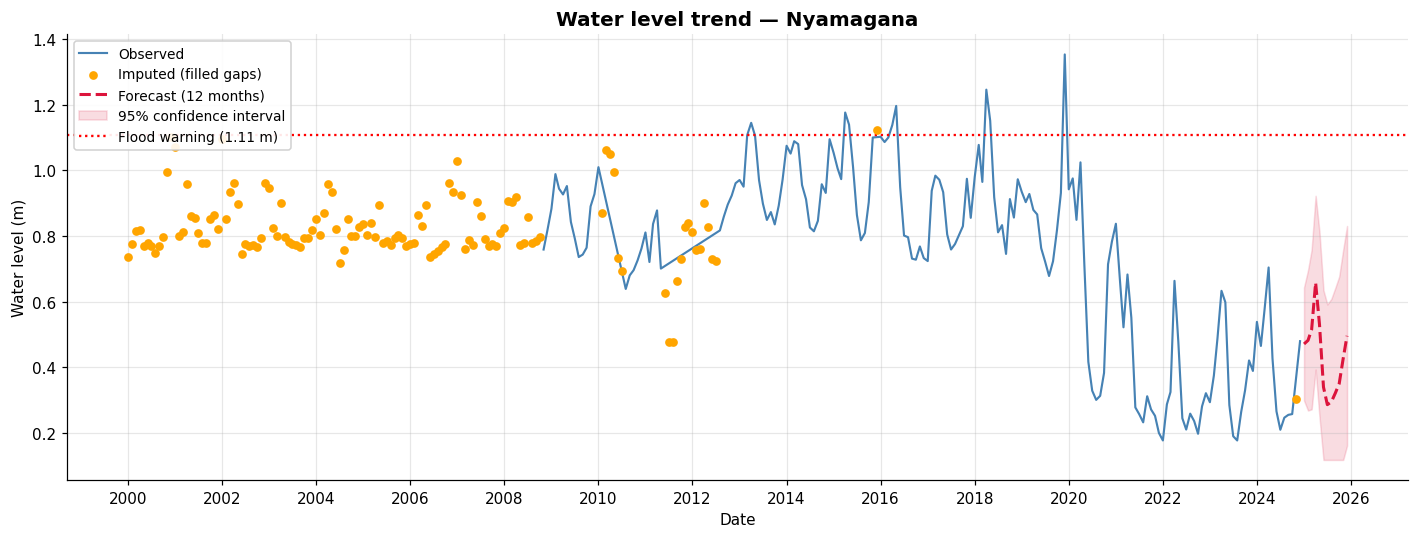

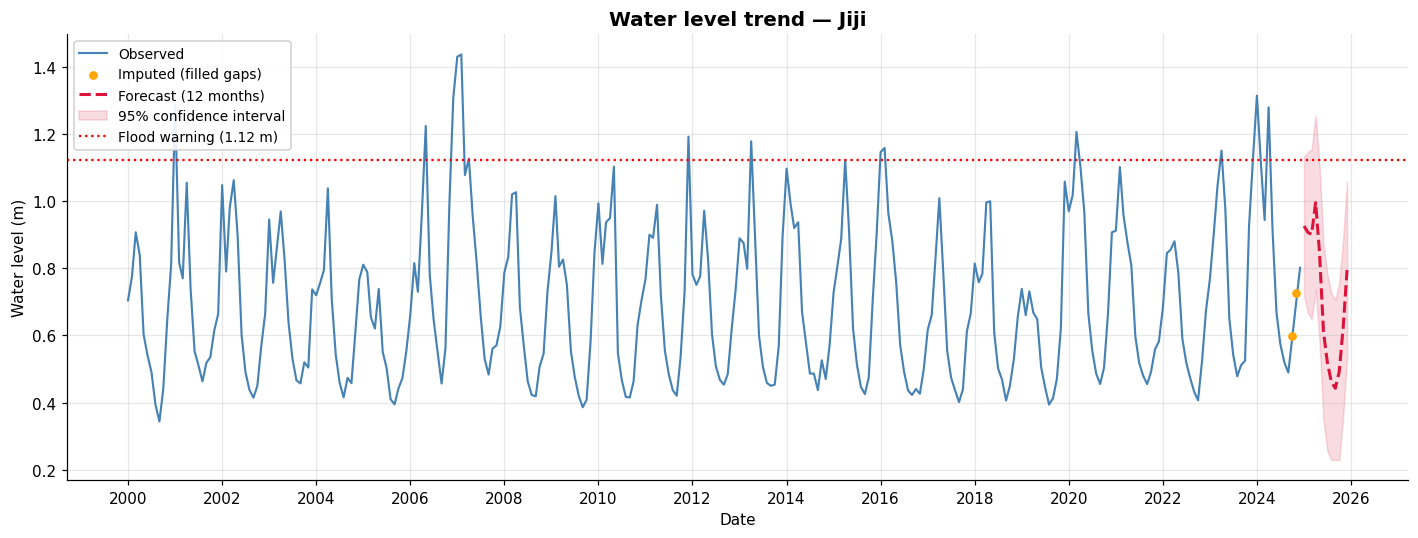

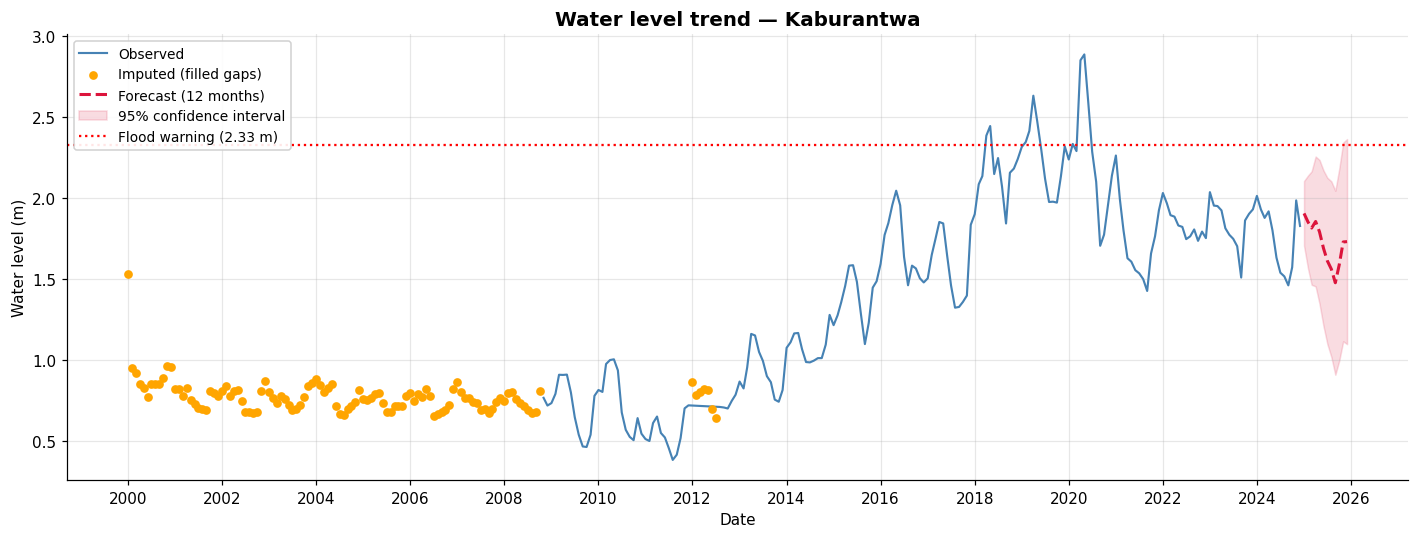

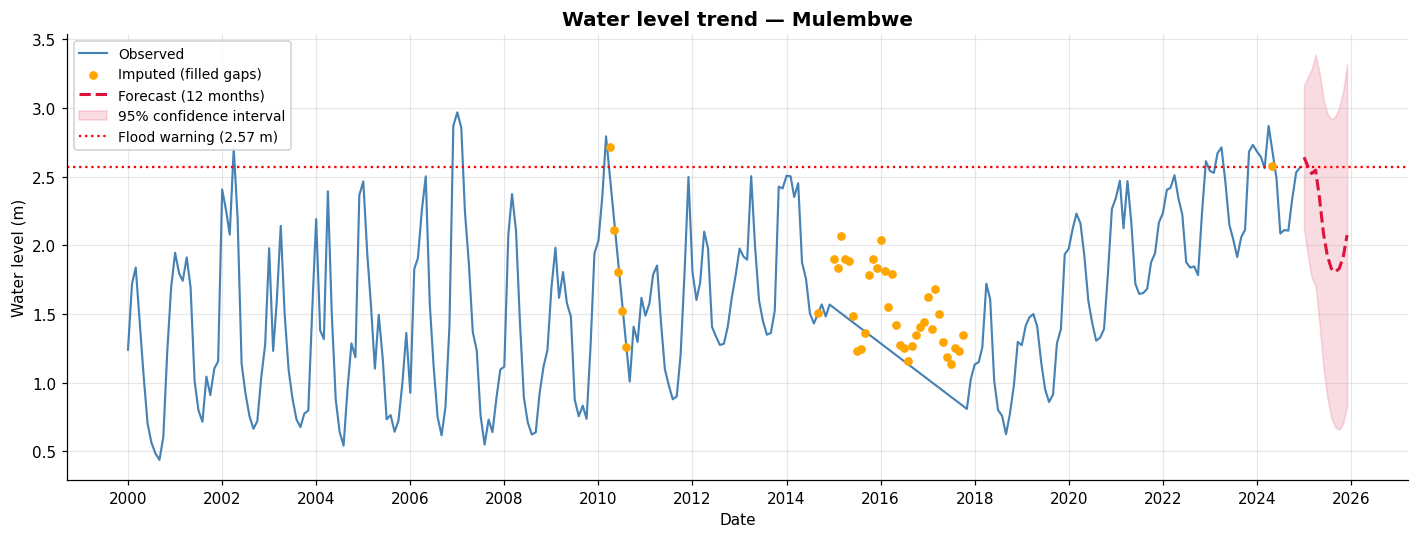

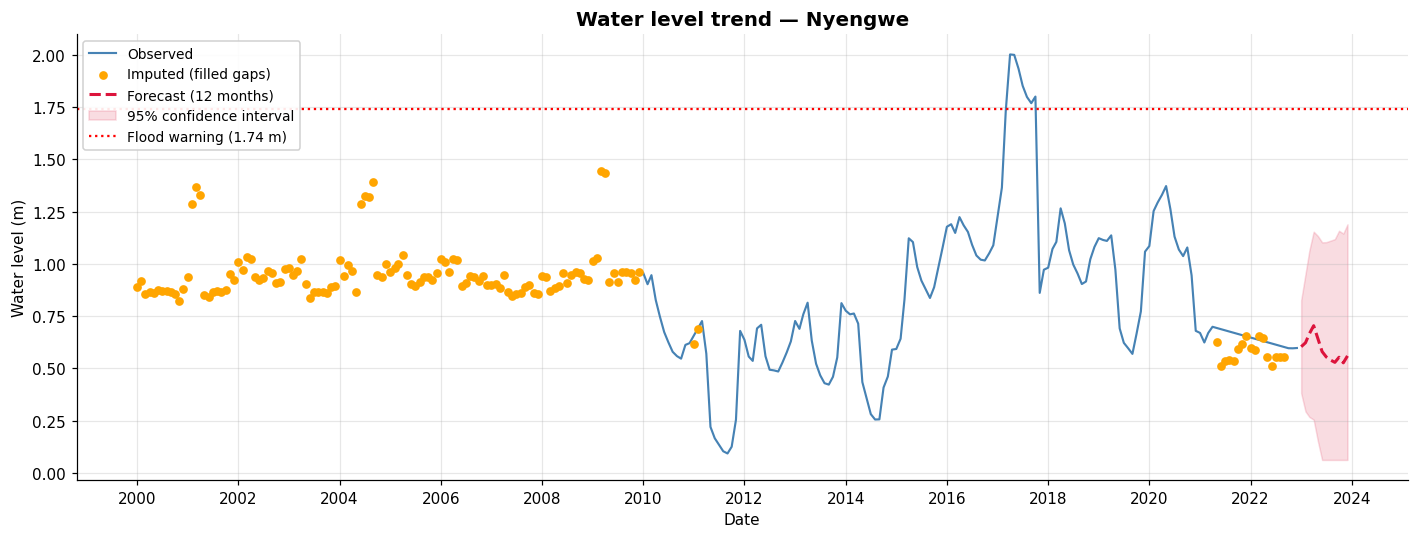

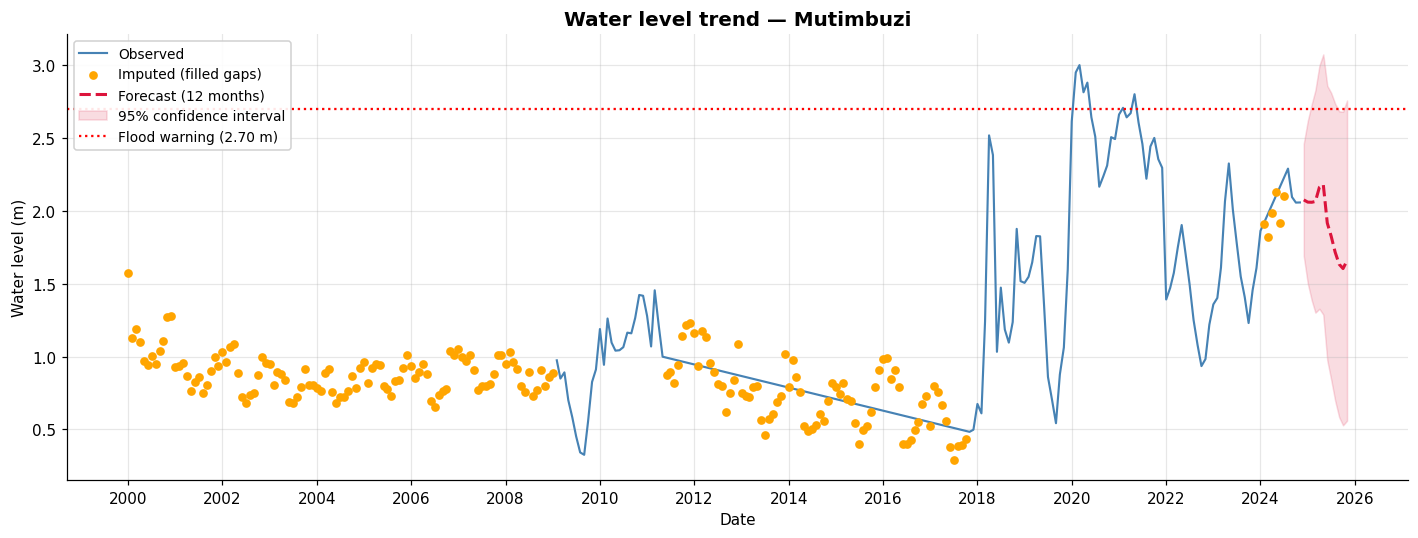

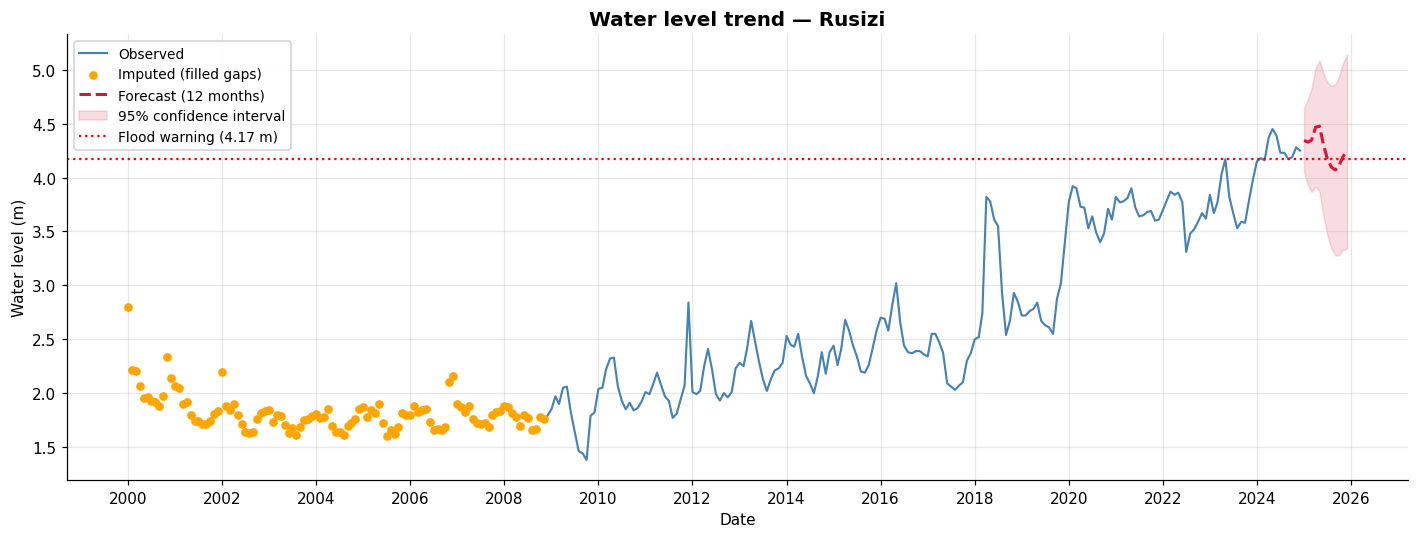

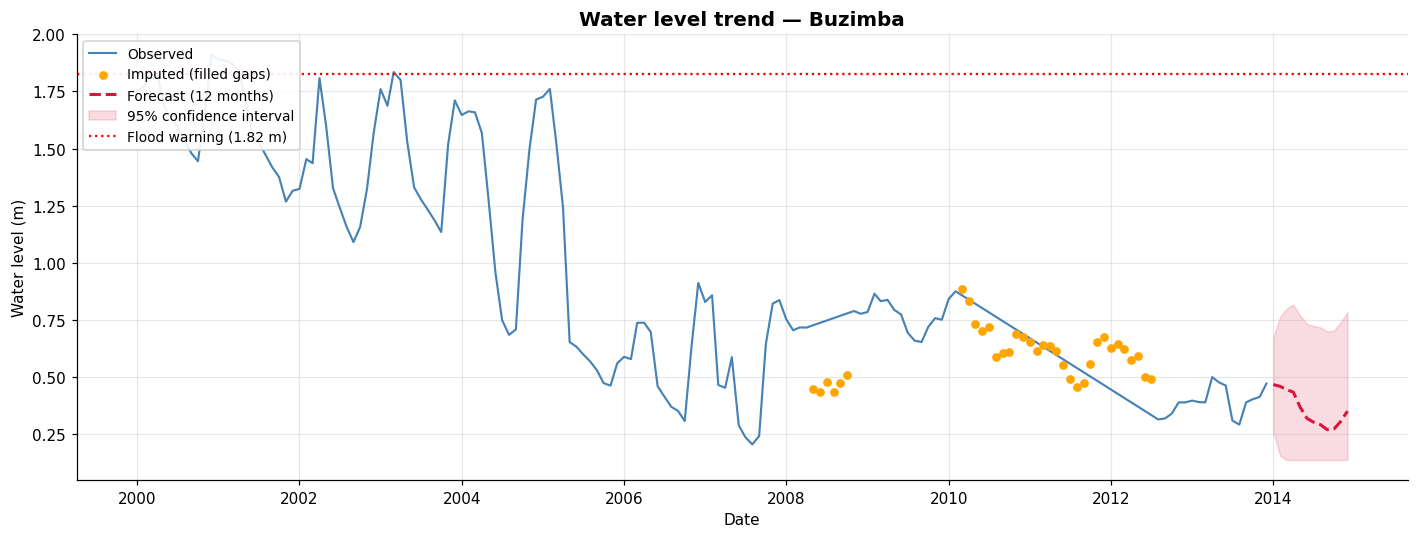

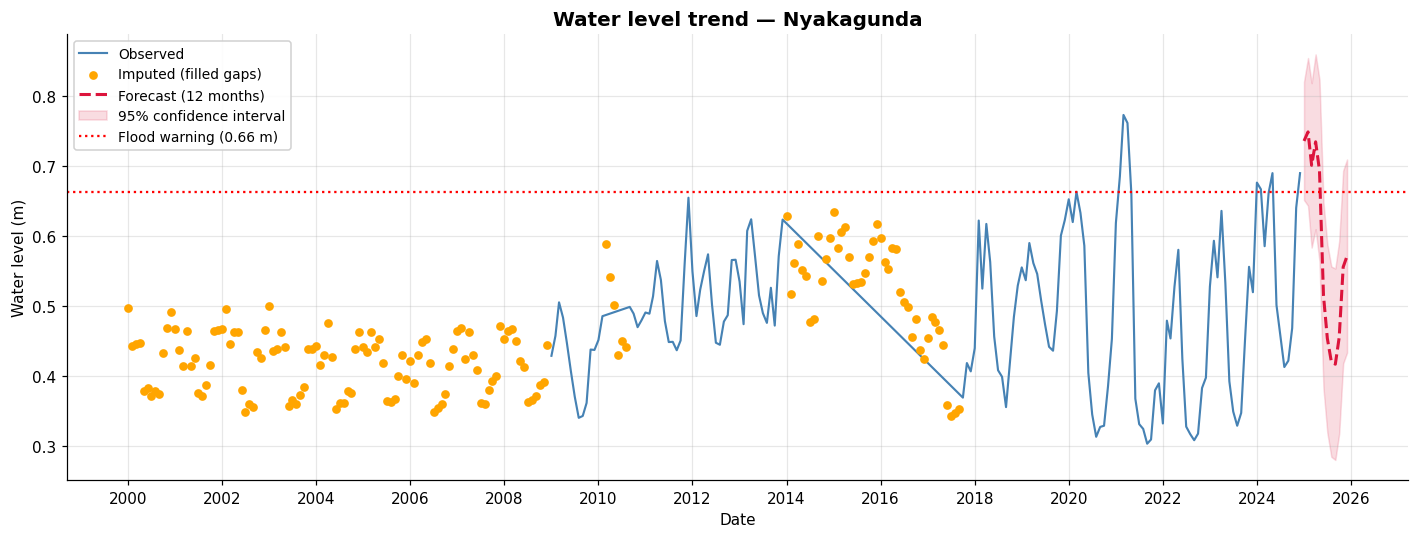

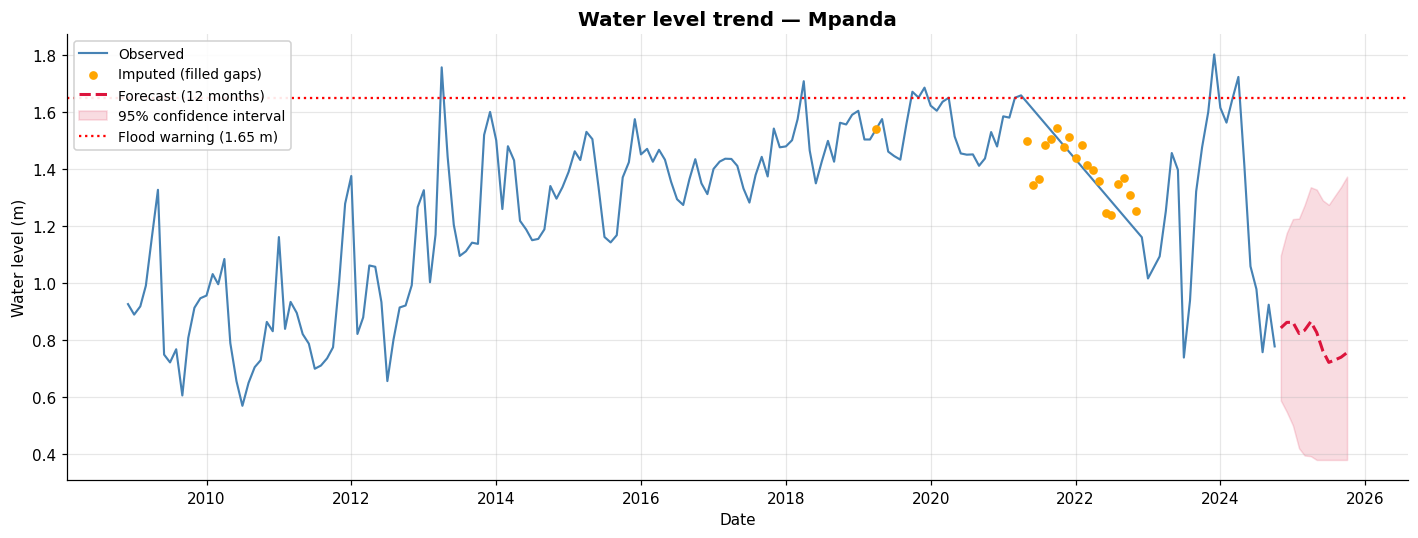

In [58]:
# ============================================================
# VISUALIZATION 1 — Water Level Trend
# ============================================================
def plot_water_level_trend(river_name, save_path=None):
    df_r = rivers_imputed[rivers_imputed[RIVER_COL] == river_name].copy().sort_index()
    fc_r = forecasts_df[forecasts_df["river"] == river_name].copy()
    threshold = flood_thresholds.get(river_name)

    observed_mask = df_r["best_model_used"] == "observed"
    imputed_mask  = (~observed_mask) & df_r["water_level_best_model_imputed"].notna()

    fig, ax = plt.subplots(figsize=(13, 5))

    # observed
    ax.plot(
        df_r.index[observed_mask],
        df_r.loc[observed_mask, "water_level_best_model_imputed"],
        color="steelblue", linewidth=1.4, label="Observed",
    )

    # imputed (different colour & style)
    ax.scatter(
        df_r.index[imputed_mask],
        df_r.loc[imputed_mask, "water_level_best_model_imputed"],
        color="orange", s=22, marker="o",
        label="Imputed (filled gaps)", zorder=3,
    )

    # forecast
    if not fc_r.empty:
        ax.plot(
            fc_r["date"], fc_r["forecast"],
            color="crimson", linewidth=2.0, linestyle="--",
            label=f"Forecast ({FORECAST_MONTHS} months)",
        )
        ax.fill_between(
            fc_r["date"], fc_r["lower_ci"], fc_r["upper_ci"],
            color="crimson", alpha=0.15, label="95% confidence interval",
        )

    # flood threshold
    if threshold is not None:
        ax.axhline(
            threshold, color="red", linestyle=":", linewidth=1.5,
            label=f"Flood warning ({threshold:.2f} m)",
        )

    ax.set_title(f"Water level trend — {river_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Water level (m)")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


# plot every river
for r in rivers_imputed[RIVER_COL].unique():
    plot_water_level_trend(r)


## 📊 Visualization 2 — Monthly vs 12-Month Rolling Average  

Plots the monthly water level together with its 12-month rolling average. The rolling average:

- removes the seasonal up-and-down noise
- highlights the **long-term direction** (rising / stable / falling)
- helps authorities detect **persistent** increases in lake or river levels


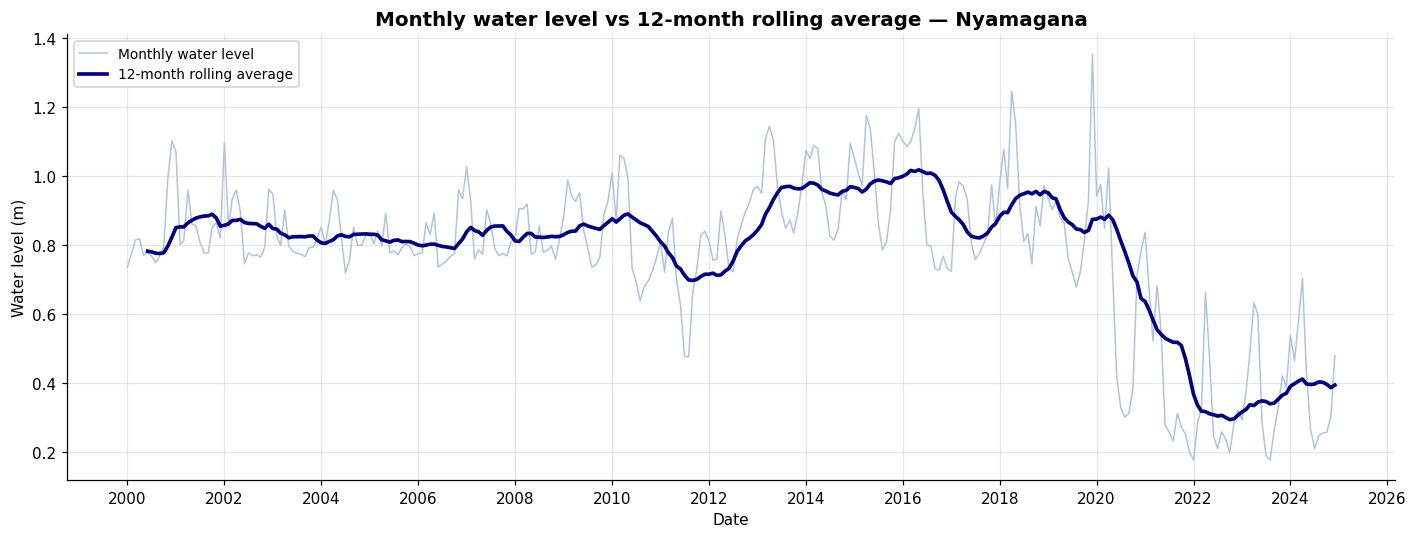

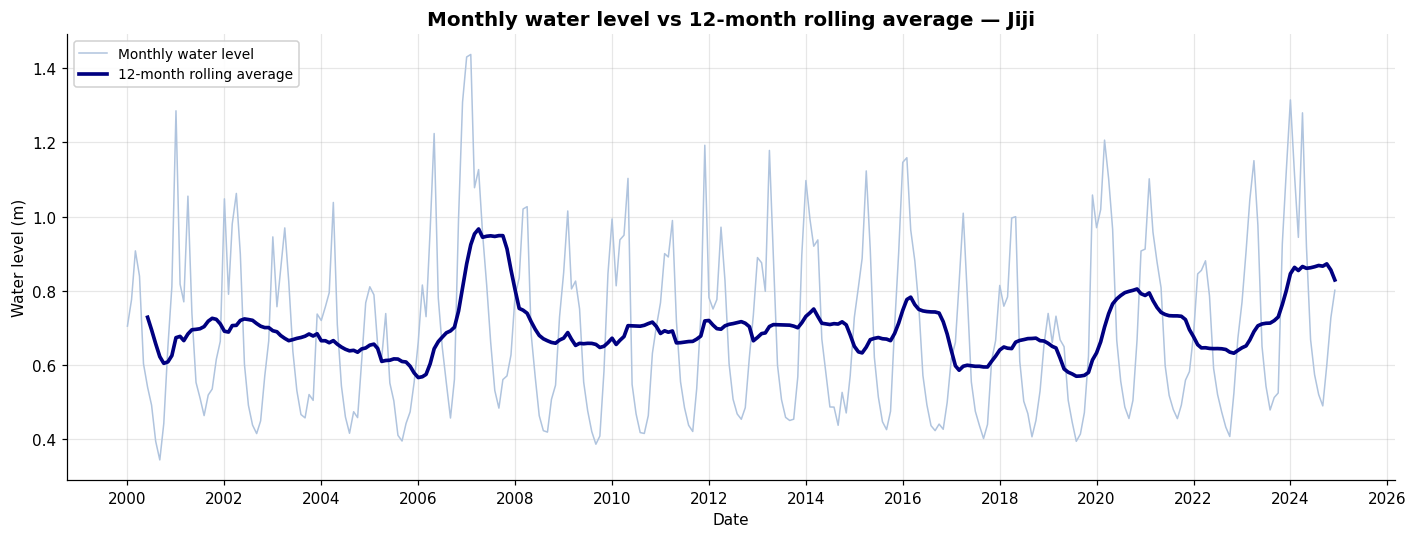

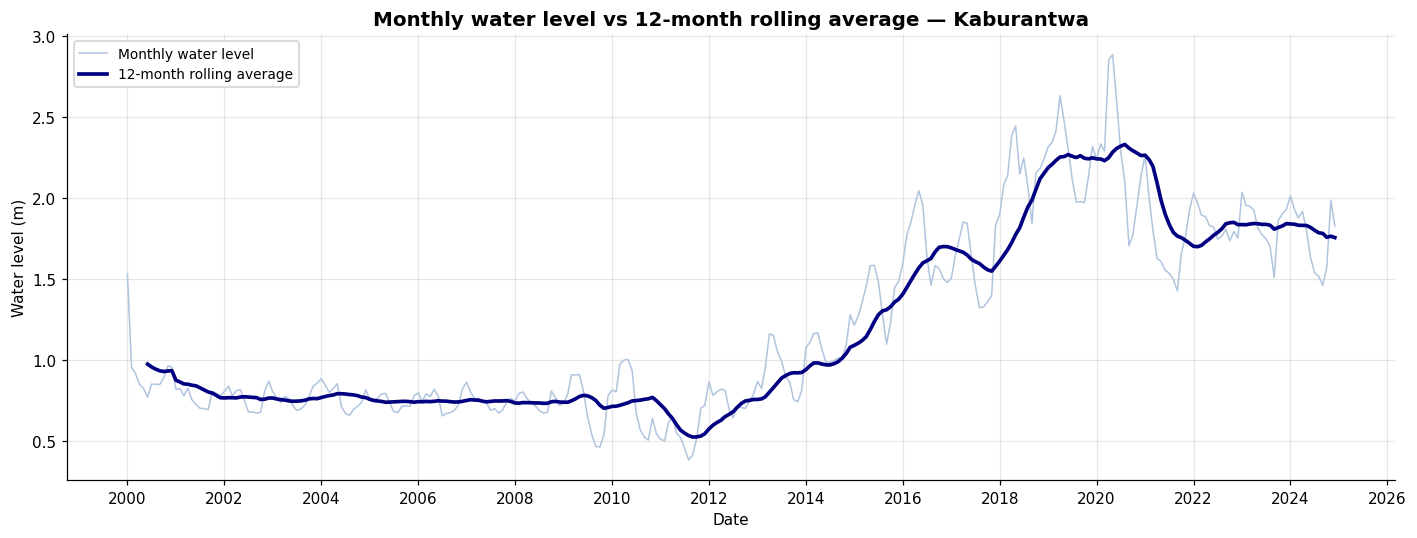

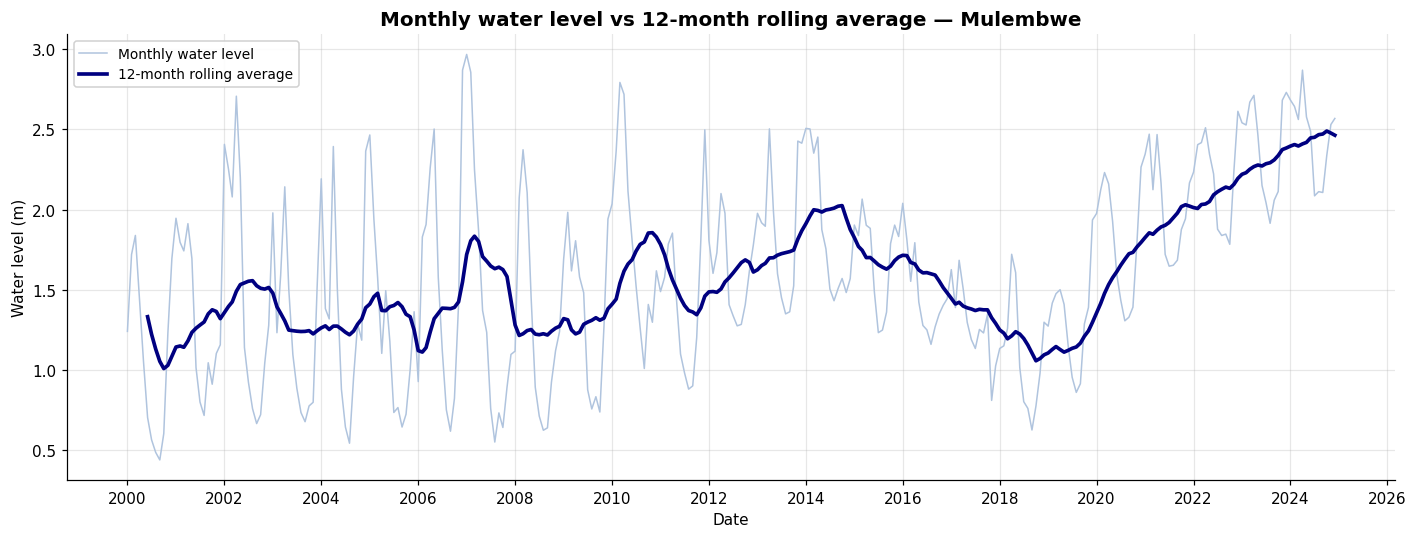

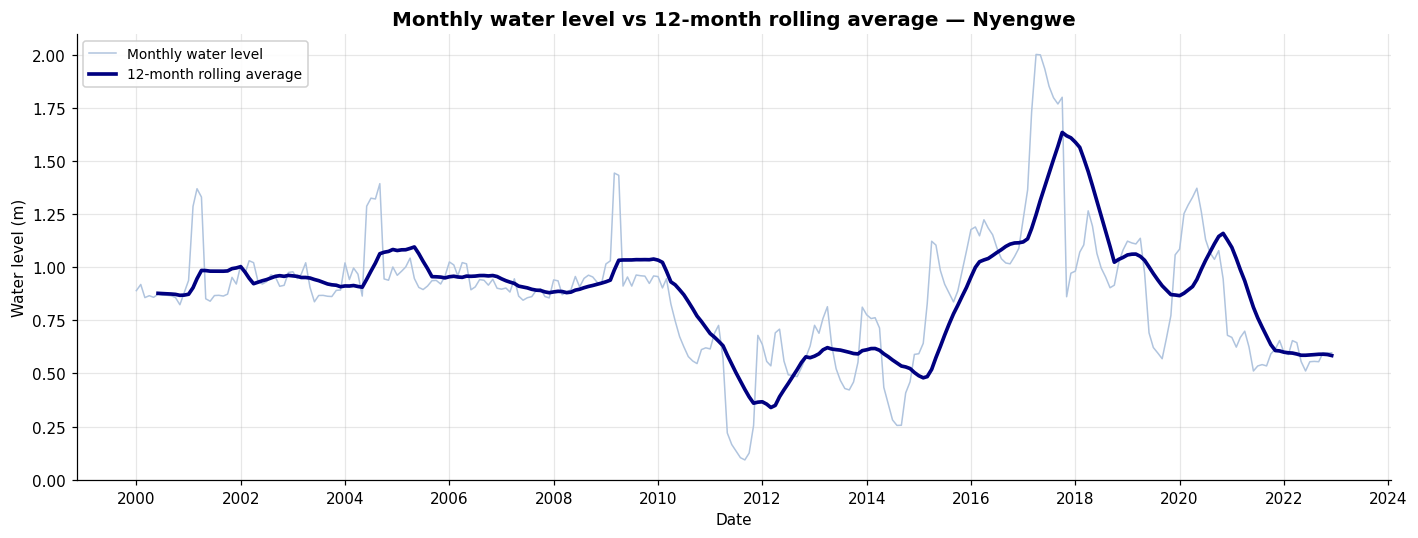

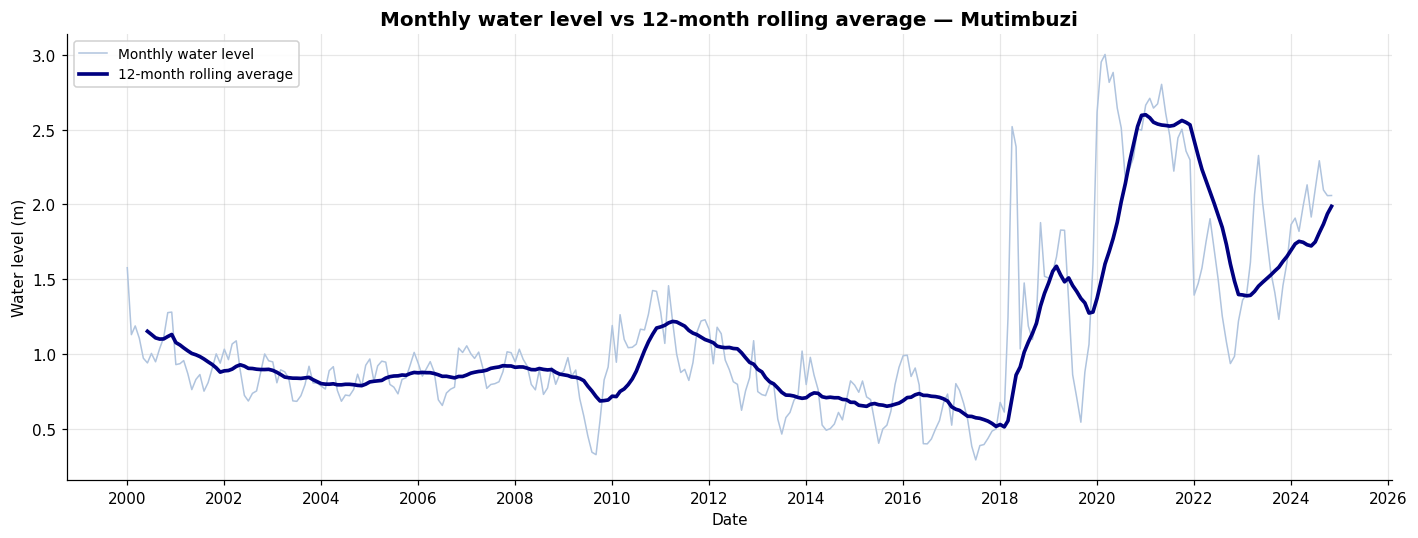

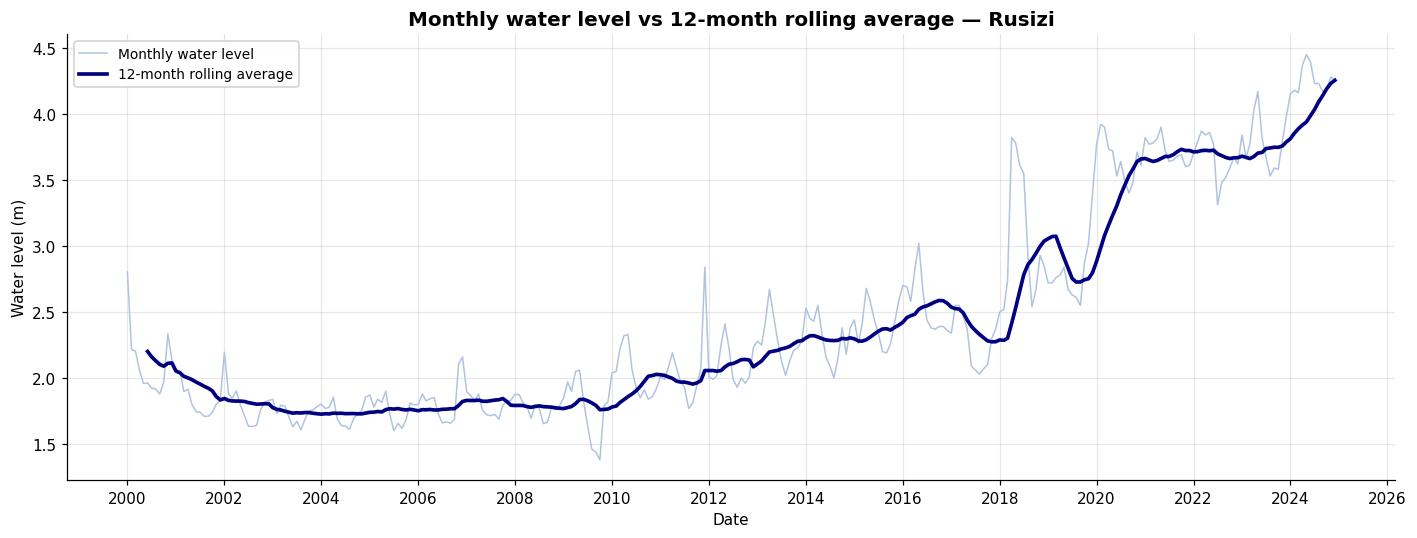

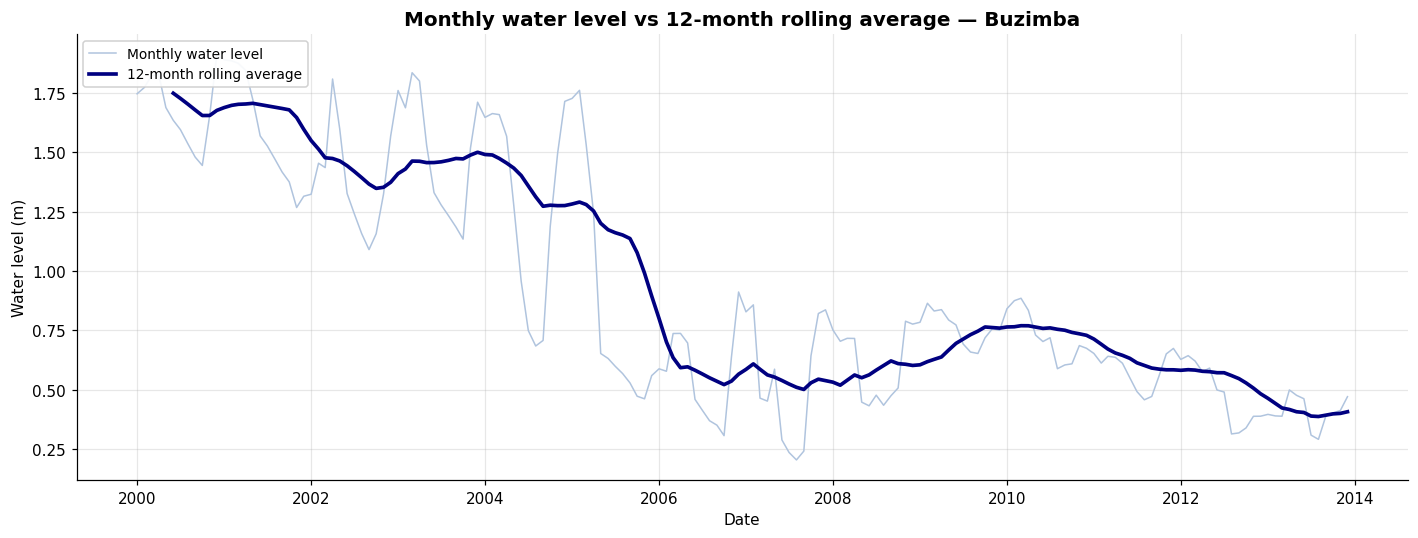

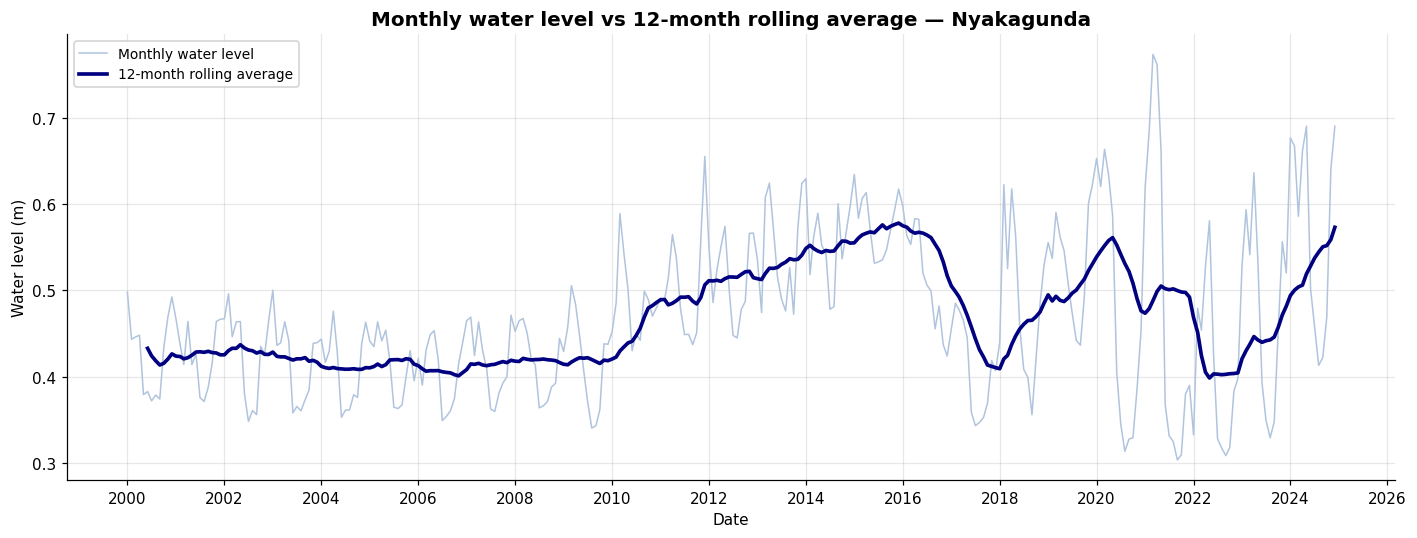

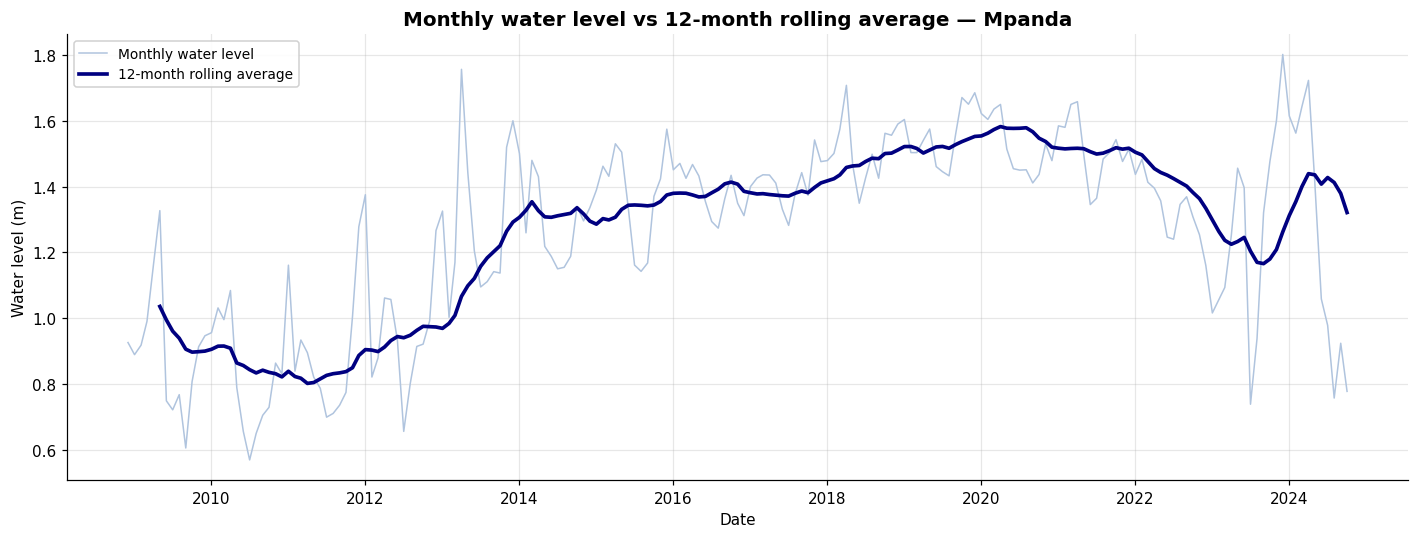

In [59]:
# ============================================================
# VISUALIZATION 2 — Monthly value vs 12-month rolling average
# ============================================================
def plot_rolling_average(river_name, window=12, save_path=None):
    df_r   = rivers_imputed[rivers_imputed[RIVER_COL] == river_name].copy().sort_index()
    series = df_r["water_level_best_model_imputed"]
    rolling = series.rolling(window=window, min_periods=max(3, window // 2)).mean()

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(series.index, series.values,
            color="lightsteelblue", linewidth=1.0,
            label="Monthly water level")

    ax.plot(rolling.index, rolling.values,
            color="navy", linewidth=2.4,
            label=f"{window}-month rolling average")

    ax.set_title(
        f"Monthly water level vs {window}-month rolling average — {river_name}",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Water level (m)")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


for r in rivers_imputed[RIVER_COL].unique():
    plot_rolling_average(r)


## Outputs you can hand off to a website

| Object                              | What it contains                                                |
|-------------------------------------|-----------------------------------------------------------------|
| `rivers_imputed`                    | Original data + one column per model + best-model column        |
| `forecasts_df`                      | 12-month forecast with confidence interval per river            |
| `flood_thresholds`                  | One number per river — the warning level                        |
| `plot_water_level_trend(river)`     | Trend chart with observed / imputed / forecast / threshold      |
| `plot_rolling_average(river)`       | Monthly + 12-month average to show long-term trend              |

You can export the dataframes to CSV/JSON and the plots to PNG for the website:

```python
rivers_imputed.to_csv("rivers_imputed.csv")
forecasts_df.to_csv("forecasts.csv", index=False)
plot_water_level_trend("Buzimba", save_path="buzimba_trend.png")
plot_rolling_average("Buzimba", save_path="buzimba_rolling.png")
```
